In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [19]:
df = pd.read_csv(
    '../data/raw/household_power_consumption.txt',
    sep=';',
    na_values=['?'],
    low_memory=False
)

In [20]:
df['datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S'
)

df.set_index('datetime', inplace=True)
df.sort_index(inplace=True)

In [21]:
df.drop(['Date', 'Time'], axis=1, inplace=True)

In [22]:
df = df.apply(pd.to_numeric)
df.interpolate(method='time', inplace=True)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...
2010-11-26 20:58:00,0.946,0.000,240.43,4.0,0.0,0.0,0.0
2010-11-26 20:59:00,0.944,0.000,240.00,4.0,0.0,0.0,0.0
2010-11-26 21:00:00,0.938,0.000,239.82,3.8,0.0,0.0,0.0


In [23]:
energy_hourly = df['Global_active_power'].resample('h').mean()
energy_hourly.interpolate(method='time', inplace=True)

datetime
2006-12-16 17:00:00    4.222889
2006-12-16 18:00:00    3.632200
2006-12-16 19:00:00    3.400233
2006-12-16 20:00:00    3.268567
2006-12-16 21:00:00    3.056467
                         ...   
2010-11-26 17:00:00    1.725900
2010-11-26 18:00:00    1.573467
2010-11-26 19:00:00    1.659333
2010-11-26 20:00:00    1.163700
2010-11-26 21:00:00    0.934667
Freq: h, Name: Global_active_power, Length: 34589, dtype: float64

In [24]:
prophet_df = energy_hourly.reset_index()
prophet_df.columns = ['ds', 'y']

prophet_df

,ds,y
0,2006-12-16 17:00:00,4.222889
1,2006-12-16 18:00:00,3.632200
2,2006-12-16 19:00:00,3.400233
3,2006-12-16 20:00:00,3.268567
4,2006-12-16 21:00:00,3.056467
...,...,...
34584,2010-11-26 17:00:00,1.725900
34585,2010-11-26 18:00:00,1.573467
34586,2010-11-26 19:00:00,1.659333
34587,2010-11-26 20:00:00,1.163700


### Prophet Model Training

Prophet is used to model time series data with strong seasonality and trend components. It automatically handles daily and weekly seasonality.

In [25]:
train_size = int(len(prophet_df) * 0.9)

train = prophet_df[:train_size]
test = prophet_df[train_size:]

In [26]:
from prophet import Prophet

model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True
)

model.fit(train)

13:50:29 - cmdstanpy - INFO - Chain [1] start processing
13:50:35 - cmdstanpy - INFO - Chain [1] done processing


In [27]:
future = model.make_future_dataframe(periods=len(test), freq='h')

future

,ds
0,2006-12-16 17:00:00
1,2006-12-16 18:00:00
2,2006-12-16 19:00:00
3,2006-12-16 20:00:00
4,2006-12-16 21:00:00
...,...
34584,2010-11-26 17:00:00
34585,2010-11-26 18:00:00
34586,2010-11-26 19:00:00
34587,2010-11-26 20:00:00


In [28]:
forecast = model.predict(future)

forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2006-12-16 17:00:00,1.399512,0.867646,2.766143,1.399512,1.399512,0.393381,0.393381,0.393381,-0.075798,...,0.170849,0.170849,0.170849,0.298329,0.298329,0.298329,0.0,0.0,0.0,1.792893
1,2006-12-16 18:00:00,1.399380,1.229945,3.078841,1.399380,1.399380,0.755424,0.755424,0.755424,0.278551,...,0.178292,0.178292,0.178292,0.298581,0.298581,0.298581,0.0,0.0,0.0,2.154804
2,2006-12-16 19:00:00,1.399248,1.617672,3.481844,1.399248,1.399248,1.169555,1.169555,1.169555,0.685618,...,0.185103,0.185103,0.185103,0.298834,0.298834,0.298834,0.0,0.0,0.0,2.568803
3,2006-12-16 20:00:00,1.399116,1.829735,3.702020,1.399116,1.399116,1.369142,1.369142,1.369142,0.878827,...,0.191226,0.191226,0.191226,0.299089,0.299089,0.299089,0.0,0.0,0.0,2.768258
4,2006-12-16 21:00:00,1.398984,1.680554,3.617188,1.398984,1.398984,1.216005,1.216005,1.216005,0.720054,...,0.196607,0.196607,0.196607,0.299344,0.299344,0.299344,0.0,0.0,0.0,2.614989
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34584,2010-11-26 17:00:00,1.117290,0.362235,2.358630,1.061601,1.178306,0.253907,0.253907,0.253907,-0.075798,...,-0.045299,-0.045299,-0.045299,0.375004,0.375004,0.375004,0.0,0.0,0.0,1.371197
34585,2010-11-26 18:00:00,1.117293,0.842569,2.628543,1.061586,1.178335,0.614545,0.614545,0.614545,0.278551,...,-0.038876,-0.038876,-0.038876,0.374870,0.374870,0.374870,0.0,0.0,0.0,1.731838
34586,2010-11-26 19:00:00,1.117296,1.190638,3.070864,1.061571,1.178365,1.028286,1.028286,1.028286,0.685618,...,-0.032064,-0.032064,-0.032064,0.374732,0.374732,0.374732,0.0,0.0,0.0,2.145582
34587,2010-11-26 20:00:00,1.117300,1.455054,3.336743,1.061550,1.178394,1.228554,1.228554,1.228554,0.878827,...,-0.024865,-0.024865,-0.024865,0.374591,0.374591,0.374591,0.0,0.0,0.0,2.345854


- yhat → prediction

- yhat_lower → lower bound

- yhat_upper → upper bound

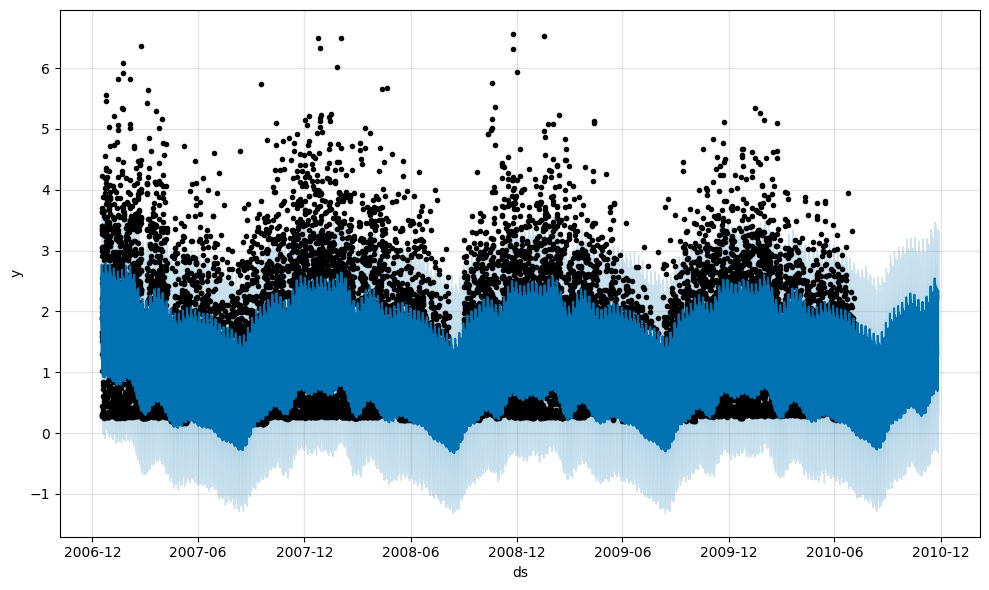

In [29]:
model.plot(forecast);

## Output

- Black dots → actual
- Blue line → prediction
- Light blue → confidence interval

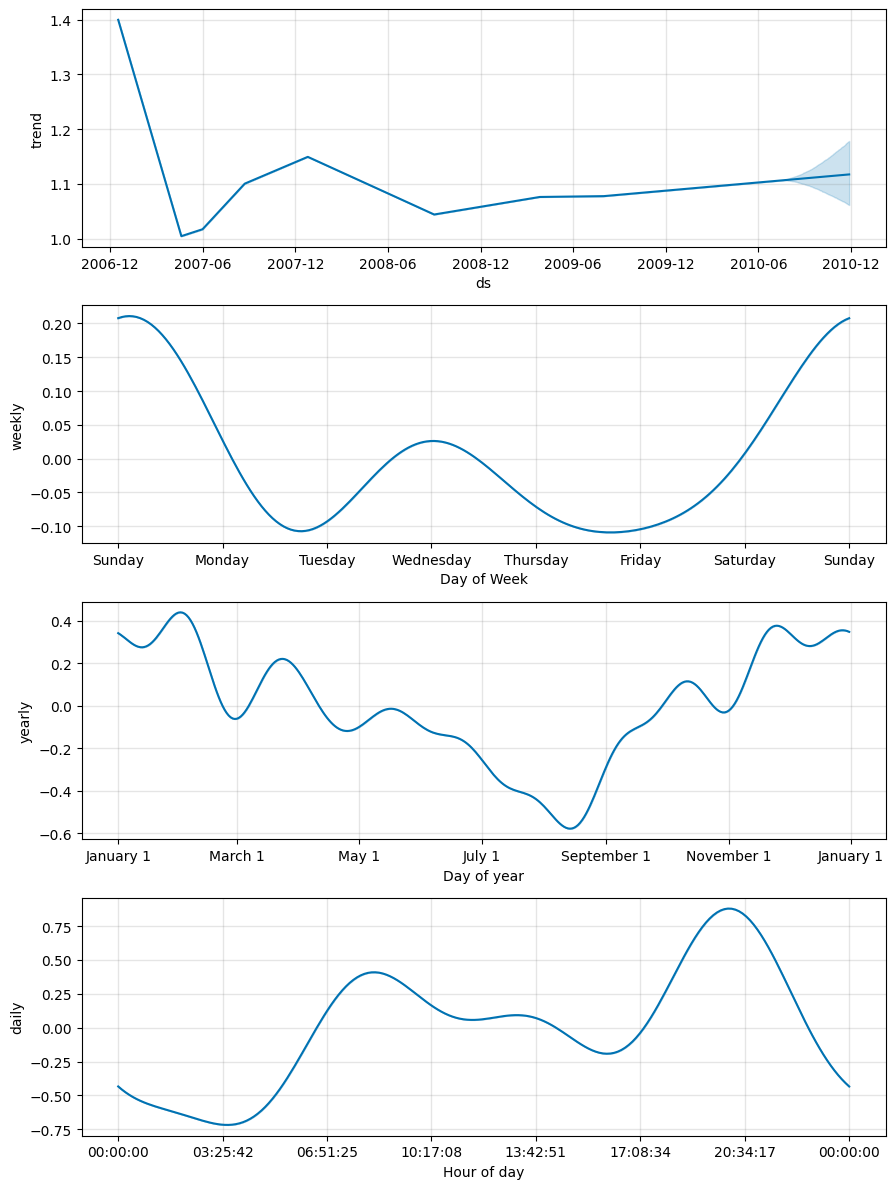

In [30]:
model.plot_components(forecast);

### Model Evaluation Strategy

The model was evaluated by forecasting the entire test set and comparing predictions with actual values using MAE and RMSE. 

A separate 24-hour forecast was generated to meet the project requirement for short-term prediction.

In [31]:
forecast_test = forecast.iloc[-len(test):]

mae = mean_absolute_error(test['y'], forecast_test['yhat'])
rmse = np.sqrt(mean_squared_error(test['y'], forecast_test['yhat']))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.49337950448162626
RMSE: 0.6395071663668623


In [32]:
def mape(y_true, y_pred):
    return (abs((y_true - y_pred) / y_true).mean()) * 100

mape_value = mape(test['y'], forecast_test['yhat'])
print("MAPE:", mape_value)

MAPE: 81.67576382191334


### Model Evaluation

The Prophet model was evaluated using MAE and RMSE.

- MAE measures average error magnitude
- RMSE penalizes larger errors more heavily
- MAPE provides a percentage-based error metric for better interpretability.

The results indicate that the model captures overall trends and seasonality effectively.

### Residual Analysis

Residuals appear randomly distributed around zero, indicating that the model has captured most of the underlying patterns in the data.

No clear patterns or trends are observed, suggesting good model performance.

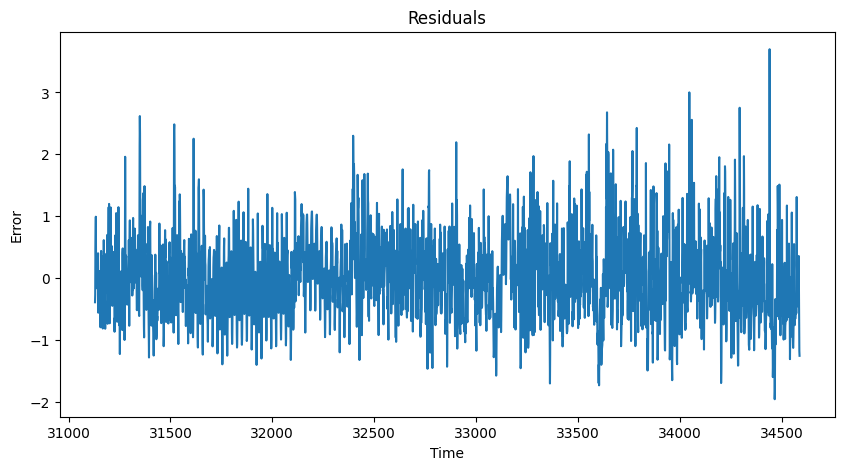

In [33]:
residuals = test['y'] - forecast_test['yhat']

plt.figure(figsize=(10,5))
plt.plot(residuals)
plt.title('Residuals')
plt.xlabel('Time')
plt.ylabel('Error')
plt.show()

### Walk-Forward Validation

A simple walk-forward validation approach was implemented by training the model on historical data and forecasting the next 24 hours.

This helps evaluate how well the model generalizes to unseen future data.

In [37]:
train_small = prophet_df[:-24]
test_small = prophet_df[-24:]

model = Prophet(daily_seasonality=True, weekly_seasonality=True)
model.fit(train_small)

future = model.make_future_dataframe(periods=24, freq='h')
forecast = model.predict(future)

pred = forecast[['ds','yhat']].tail(24)

mae_wf = mean_absolute_error(test_small['y'], pred['yhat'])
print("Walk-forward MAE:", mae_wf)

13:52:10 - cmdstanpy - INFO - Chain [1] start processing
13:52:19 - cmdstanpy - INFO - Chain [1] done processing


Walk-forward MAE: 0.3954184598376349


In [38]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(24)

,ds,yhat,yhat_lower,yhat_upper
34565,2010-11-25 22:00:00,1.617157,0.698532,2.538937
34566,2010-11-25 23:00:00,1.190685,0.263154,2.108523
34567,2010-11-26 00:00:00,0.910777,-0.027734,1.777584
34568,2010-11-26 01:00:00,0.785602,-0.074392,1.777184
34569,2010-11-26 02:00:00,0.717959,-0.243196,1.583951
34570,2010-11-26 03:00:00,0.651645,-0.283729,1.560582
34571,2010-11-26 04:00:00,0.646728,-0.251355,1.560348
34572,2010-11-26 05:00:00,0.806905,-0.152752,1.728832
34573,2010-11-26 06:00:00,1.140471,0.254510,2.051650
34574,2010-11-26 07:00:00,1.507846,0.533691,2.426661


In [39]:
future_24 = model.make_future_dataframe(periods=24, freq='h')
forecast_24 = model.predict(future_24)

forecast_24[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(24)

,ds,yhat,yhat_lower,yhat_upper
34565,2010-11-25 22:00:00,1.617157,0.678174,2.484811
34566,2010-11-25 23:00:00,1.190685,0.259466,2.070227
34567,2010-11-26 00:00:00,0.910777,0.022444,1.857921
34568,2010-11-26 01:00:00,0.785602,-0.086398,1.740971
34569,2010-11-26 02:00:00,0.717959,-0.206892,1.608424
34570,2010-11-26 03:00:00,0.651645,-0.240722,1.548764
34571,2010-11-26 04:00:00,0.646728,-0.277777,1.659726
34572,2010-11-26 05:00:00,0.806905,-0.193992,1.769979
34573,2010-11-26 06:00:00,1.140471,0.209667,2.122444
34574,2010-11-26 07:00:00,1.507846,0.572706,2.420583


### Key Observations

- Prophet effectively captures daily and weekly seasonality.
- The model provides uncertainty intervals, which are useful for decision-making.
- Forecasts align well with historical trends.